**What you will learn in this notebook**

By the end of this notebook, you will understand:

What classification is

What logistic regression does

How data is loaded, split, and scaled


*   What classification is
*   What logistic regression does

*   How data is loaded, split, and scaled
*   How a classification model is trained

*   How predictions are made and evaluated




**Step 1: Import required libraries**

In [ ]:
# Numerical and data handling
import pandas as pd

# Machine learning utilities
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


**Step 2: Load the Iris dataset**

The Iris dataset contains following measurements of flowers:

Sepal length

1.   Sepal length
2.   Sepal width


1.   Petal length
2.   Petal width


The goal is to classify each flower into one of three species
### 🌸 The Iris Dataset

The Iris dataset contains measurements of **three different categories of flowers**:

- Setosa
- Versicolor
- Virginica

Each flower belongs to **exactly one category**.

In this notebook, our goal is to use these measurements to **classify a flower into one of the three species**.

In [ ]:
# Load Iris dataset
iris = load_iris()

# Features (X): measurements
X = iris.data

# Target labels (y): flower species
y = iris.target

# Display dataset information
print("Feature names:", iris.feature_names)
print("Target classes:", iris.target_names)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']


**Step 3: Inspect the data**

Let’s convert the data into a table to better understand it.

In [ ]:
df = pd.DataFrame(X, columns=iris.feature_names)
df['Species'] = pd.Categorical.from_codes(y, iris.target_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**Step 4: Split the dataset into training and testing sets**
We split the data so that:

70% is used for training the model

30% is used to test how well the model generalizes

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 105
Testing samples: 45


**Step 5: Scale the features**


Logistic regression works better when features are on a similar scale.
We standardize the data so each feature has:

Mean = 0

Standard deviation = 1

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train the Logistic Regression model


Logistic Regression learns the relationship between the input features and class labels.

In [ ]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

**Step 7: Make predictions on new (test) data**


Now the model predicts which species each test flower belongs to.

In [ ]:
y_pred = model.predict(X_test_scaled)

Step 8: Evaluate model performance

Accuracy

Accuracy tells us what percentage of predictions were correct.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Classification Accuracy: {accuracy:.2f}")

Classification Accuracy: 0.96


**Detailed classification report**

This shows:

Precision

Recall

F1-score
for each class.

In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       0.94      0.94      0.94        18
   virginica       0.92      0.92      0.92        13

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



**Step 9: View predictions alongside actual values**


This helps us visually compare:

What the true species is

What the model predicted

In [ ]:
df_test = pd.DataFrame(X_test, columns=iris.feature_names)

df_test['Actual Species'] = pd.Categorical.from_codes(
    y_test, iris.target_names
)

df_test['Predicted Species'] = pd.Categorical.from_codes(
    y_pred, iris.target_names
)

df_test.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Actual Species,Predicted Species
0,5.8,4.0,1.2,0.2,setosa,setosa
1,5.1,2.5,3.0,1.1,versicolor,versicolor
2,6.6,3.0,4.4,1.4,versicolor,versicolor
3,5.4,3.9,1.3,0.4,setosa,setosa
4,7.9,3.8,6.4,2.0,virginica,virginica


## 📈 Step 10: Visualizing Decision Boundaries

To understand how logistic regression separates different classes, we visualize
the decision boundaries learned by the model.

For visualization, we use **only two features**:
- Petal length
- Petal width

This allows us to plot the classification regions in 2D.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Select two features for visualization (petal length & petal width)
X_vis = iris.data[:, [2, 3]]
y_vis = iris.target

feature_names = [iris.feature_names[2], iris.feature_names[3]]


Step 10.2: Split and scale (for visualization model)

In [ ]:
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis, y_vis, test_size=0.3, random_state=1
)

scaler_vis = StandardScaler()
X_train_vis_scaled = scaler_vis.fit_transform(X_train_vis)
X_test_vis_scaled = scaler_vis.transform(X_test_vis)


Step 10.3: Train logistic regression (2 features)

In [ ]:
model_vis = LogisticRegression()
model_vis.fit(X_train_vis_scaled, y_train_vis)


LogisticRegression()

Step 10.4: Create a mesh grid

In [ ]:
x_min, x_max = X_train_vis_scaled[:, 0].min() - 1, X_train_vis_scaled[:, 0].max() + 1
y_min, y_max = X_train_vis_scaled[:, 1].min() - 1, X_train_vis_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)


Step 10.5: Predict over the grid

In [ ]:
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


**Step 10.6: Plot decision boundaries**

On the decision boundary plot:

- Different colors represent the different classes predicted by the model.
- Each point is a flower from the training set.



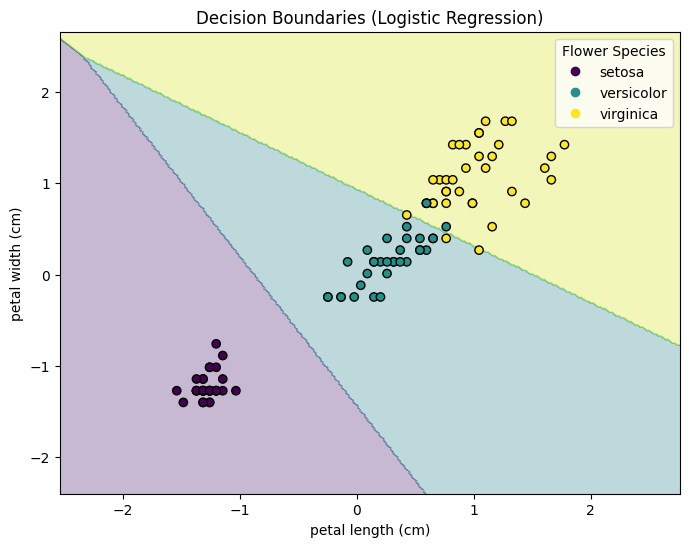

In [ ]:
plt.figure(figsize=(8, 6))

# Decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Training data points
scatter = plt.scatter(
    X_train_vis_scaled[:, 0],
    X_train_vis_scaled[:, 1],
    c=y_train_vis,
    edgecolor="k"
)

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Decision Boundaries (Logistic Regression)")

# Correct legend handling
handles, _ = scatter.legend_elements()
plt.legend(handles, iris.target_names, title="Flower Species")

plt.show()

